In [1]:
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from tqdm.notebook import tnrange, tqdm_notebook
from pytorch_lightning.loggers import CSVLogger
import torch.nn as nn
from torch.optim import Adam

import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import sys
from models.resnets import ResNetAutoencoder

sys.path.append("../_Segmentation Model/")
sys.path.append("../")

import utils
from transforms import MaskResize, InstanceMaskCropper, PadToSizeTensor, MinMaxNormalize

In [2]:
image_data = pd.read_csv('image_data.csv')

In [3]:
class AEDataset(Dataset):
    def __init__(self, image_data, threshold=None, transforms=None):
        if threshold is not None:
            df = image_data.query("height > @threshold and width > @threshold")
        else:
            df = image_data

        self.image_data = df[['version', 'image_path', 'height']].sort_values(
            by='height'
        ).reset_index(drop=True)

        self.image_paths = self.image_data['image_path'].tolist()

        self.transforms = transforms

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

        if self.transforms is not None:
            image = self.transforms(image)

        return image

    def __len__(self):
        return len(self.image_paths)

In [4]:
trans = transforms.Compose([
    transforms.ToTensor(),
    # PadToSizeTensor(3500, 3500),
    transforms.Resize(size=(500, 500)),
    MinMaxNormalize()
])

utils.set_seed()
batch_size = 16
all_dataset = AEDataset(image_data, 250, trans)
all_dataset.image_data = all_dataset.image_data[all_dataset.image_data['version'] == '_separated']
train_set, val_set, test_set = random_split(all_dataset, [0.7, 0.2, 0.1])

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

In [5]:
def visualize_batch(x):
    fig, axs = plt.subplots(nrows=2, ncols=8, figsize=(16, 4))
    
    idx = 0
    for row in range(2):
        for col in range(8):
            axs[row, col].imshow(x[idx].permute(1,2,0))
            axs[row, col].axis('off')
            idx += 1
    
    plt.tight_layout()
    plt.show()

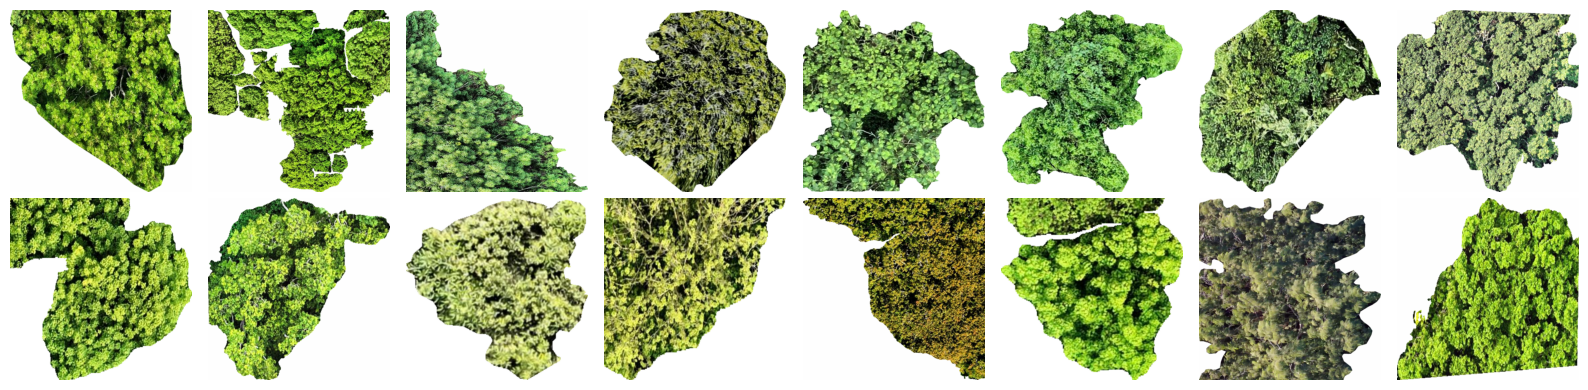

In [6]:
for batch in train_loader:
    visualize_batch(batch)
    break

In [7]:
import pytorch_lightning as pl
import torch

class LitAutoencoder(pl.LightningModule):
    def __init__(self, architecture, lr=1e-4):
        super().__init__()
        self.model = architecture
        self.loss_fn = nn.MSELoss()
        self.lr = lr

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        imgs = batch
        outputs = self(imgs)
        loss = self.loss_fn(outputs, imgs)
        self.log("train_loss", loss, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        imgs = batch
        outputs = self(imgs)
        loss = self.loss_fn(outputs, imgs)
        self.log("val_loss", loss, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        return Adam(self.parameters(), lr=self.lr)

In [8]:
csv_logger = CSVLogger("logs", name="autoencoder_run")

In [9]:
trainer = pl.Trainer(
    max_epochs=30,
    accelerator="auto",
    devices="auto",
    logger=csv_logger,
)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [10]:
arch = ResNetAutoencoder(model_name='resnet34', pretrained=False)
model = LitAutoencoder(arch, lr=1e-4)

In [11]:
trainer.fit(
    model,
    train_loader,
    val_loader
)

You are using a CUDA device ('NVIDIA GeForce RTX 4060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | model   | ResNetAutoencoder | 23.0 M | train
1 | loss_fn | MSELoss           | 0      | train
------------------------------------------------------
23.0 M    Trainable params
0         Non-trainable params
23.0 M    Total params
92.100    Total estimated model params size (MB)
134       Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                               | 0/? [00:00<…

C:\Users\Brian\anaconda3\envs\dl_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.
C:\Users\Brian\anaconda3\envs\dl_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=30` reached.


In [12]:
scores = pd.read_csv('logs/autoencoder_run/version_5/metrics.csv')

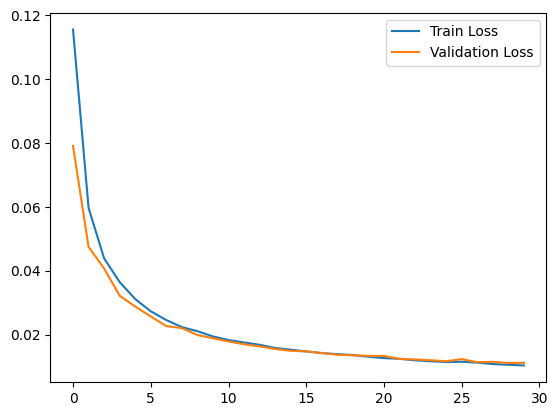

In [14]:
scores['train_loss'].dropna().reset_index(drop=True).plot(label='Train Loss')
scores['val_loss'].dropna().reset_index(drop=True).plot(label='Validation Loss')
plt.legend()

In [20]:
model = LitAutoencoder.load_from_checkpoint(
    "logs/autoencoder_run/version_5/checkpoints/epoch=29-step=1530.ckpt",
    architecture=ResNetAutoencoder(model_name="resnet34", pretrained=False)
)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()
model.to(device)

LitAutoencoder(
  (model): ResNetAutoencoder(
    (autopad): AutoPad2d()
    (encoder): ResNetEncoder(
      (encoder): Sequential(
        (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (4): Sequential(
          (0): BasicBlock(
            (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (relu): ReLU(inplace=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (1): BasicBlock(
            (conv1): Conv2d(64, 64, ker

In [21]:
latents = []
recons = []
originals = []


with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)

        # --- Encode ---
        z = model.model.encoder(batch)  
        latents.append(z.cpu())

        # --- Reconstruct ---
        out = model.model.decoder(z)
        recons.append(out.cpu())

        originals.append(batch.cpu())

In [22]:
xtest = next(iter(test_loader))

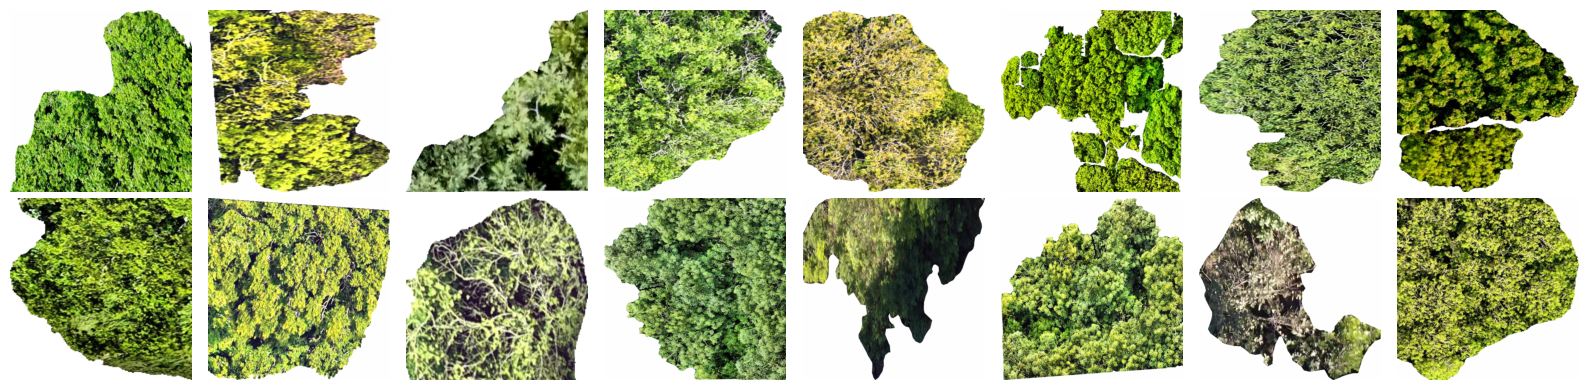

In [23]:
fig, axs = plt.subplots(nrows=2, ncols=8, figsize=(16, 4))

idx = 0
for row in range(2):
    for col in range(8):
        axs[row, col].imshow(xtest[idx].permute(1,2,0))
        axs[row, col].axis('off')
        idx += 1

plt.tight_layout()
plt.show()

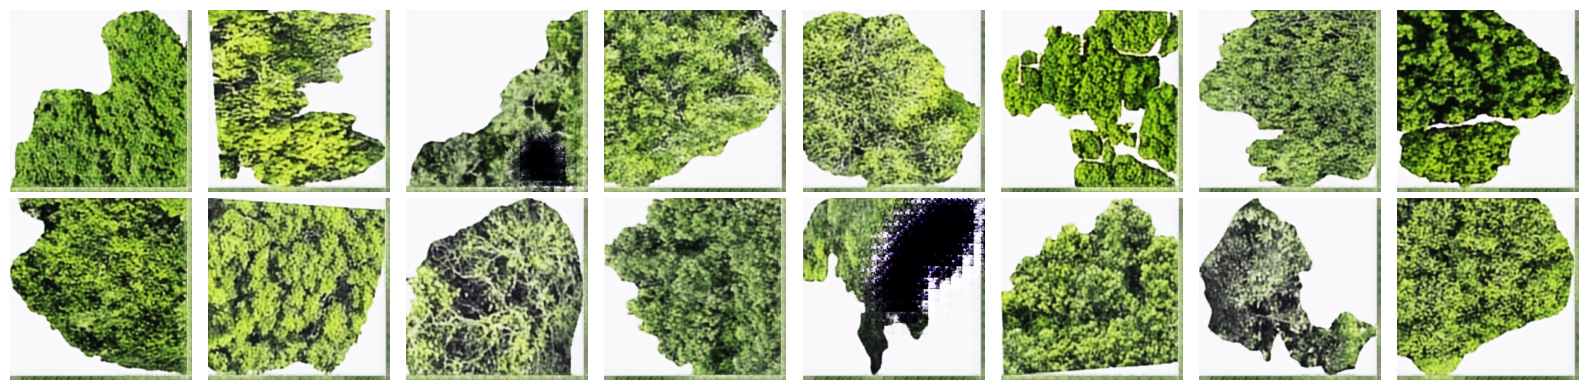

In [24]:
fig, axs = plt.subplots(nrows=2, ncols=8, figsize=(16, 4))

idx = 0
for row in range(2):
    for col in range(8):
        axs[row, col].imshow(recons[0][idx].permute(1,2,0))
        axs[row, col].axis('off')
        idx += 1

plt.tight_layout()
plt.show()

In [47]:
def predict(image):
    model.eval()
    with torch.no_grad():
        image = image.unsqueeze(dim=0).to(device)

        # --- Encode ---
        z = model.model.encoder(image)  
        # latents.append(z.cpu())

        # --- Reconstruct ---
        out = model.model.decoder(z)
        # recons.append(out.cpu())

        return z.cpu(), out.cpu()

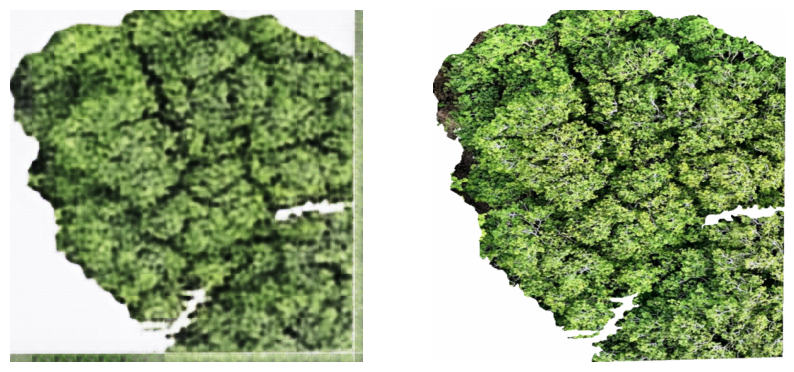

In [67]:
idx = -1
z, recon = predict(test_set[idx])

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(recon.squeeze(dim=0).permute(1,2,0))
axs[1].imshow(test_set[idx].permute(1,2,0))
axs[0].axis('off')
axs[1].axis('off')
plt.show()

In [70]:
Z = torch.stack([z_i.view(-1) for z_i in z])